In [1]:
import importlib
import data_prep
import features

In [2]:
importlib.reload(data_prep)
importlib.reload(features)

<module 'features' from 'c:\\Users\\User\\Desktop\\test_proj\\ml\\features.py'>

# Prepare Dataset

In [3]:
df = data_prep.prepare_dataset()

Districts:  ['中正區', '文山區', '大同區', '萬華區', '內湖區', '中山區', '士林區', '大安區', '信義區', '松山區', '南港區', '北投區']
Building_type:  ['華廈(10層含以下有電梯)', '住宅大樓(11層含以上有電梯)', '公寓(5樓含以下無電梯)']


In [4]:
df.head(10)

,final_price_per_sqm,area,main_area,net_area,parking_area,total_floors,floor_level,building_year,building_age,transaction_year,...,district_北投區,district_南港區,district_士林區,district_大同區,district_大安區,district_文山區,district_松山區,district_萬華區,building_type_公寓(5樓含以下無電梯),building_type_華廈(10層含以下有電梯)
0,129467,19.32,14.01,19.32,0.00,7,2.0,1980.0,46.0,2026,...,False,False,False,False,False,False,False,False,False,True
1,272458,30.39,16.91,30.39,0.00,10,4.0,2008.0,18.0,2026,...,False,False,False,False,False,True,False,False,False,True
2,76594,91.13,81.23,91.13,0.00,7,-1.0,1978.0,48.0,2026,...,False,False,False,False,False,False,False,False,False,True
3,264174,98.42,72.77,98.42,0.00,7,1.0,1991.0,35.0,2026,...,False,False,False,True,False,False,False,False,False,True
4,459600,89.58,31.79,53.96,35.62,12,7.0,2026.0,0.0,2026,...,False,False,False,False,False,False,False,False,False,False
5,58140,6.02,6.02,6.02,0.00,4,1.0,1970.0,56.0,2026,...,False,False,False,False,False,False,False,True,True,False
6,319326,128.75,57.89,90.19,38.56,14,12.0,2005.0,21.0,2026,...,False,False,False,False,False,False,False,False,False,False
7,334330,200.70,136.51,200.70,0.00,14,1.0,2004.0,22.0,2026,...,False,False,False,False,False,False,False,False,False,False
8,176639,45.46,45.46,45.46,0.00,4,4.0,1968.0,58.0,2026,...,False,False,False,False,False,False,False,False,True,False
9,290121,52.84,37.71,52.84,0.00,6,2.0,1994.0,32.0,2026,...,False,False,True,False,False,False,False,False,False,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 0 to 176
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   final_price_per_sqm          171 non-null    int64  
 1   area                         171 non-null    float64
 2   main_area                    171 non-null    float64
 3   net_area                     171 non-null    float64
 4   parking_area                 171 non-null    float64
 5   total_floors                 171 non-null    int64  
 6   floor_level                  171 non-null    float64
 7   building_year                171 non-null    float64
 8   building_age                 171 non-null    float64
 9   transaction_year             171 non-null    int32  
 10  transaction_month            171 non-null    int32  
 11  area_ratio                   171 non-null    float64
 12  time_index                   171 non-null    int32  
 13  log_area                 

In [6]:
df.isna().sum()

final_price_per_sqm            0
area                           0
main_area                      0
net_area                       0
parking_area                   0
total_floors                   0
floor_level                    0
building_year                  0
building_age                   0
transaction_year               0
transaction_month              0
area_ratio                     0
time_index                     0
log_area                       0
has_parking                    0
district_中正區                   0
district_信義區                   0
district_內湖區                   0
district_北投區                   0
district_南港區                   0
district_士林區                   0
district_大同區                   0
district_大安區                   0
district_文山區                   0
district_松山區                   0
district_萬華區                   0
building_type_公寓(5樓含以下無電梯)     0
building_type_華廈(10層含以下有電梯)    0
dtype: int64

# Perform Train Test Split

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop(columns=['final_price_per_sqm'])
y = df['final_price_per_sqm']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [9]:
X_train.describe()

,area,main_area,net_area,parking_area,total_floors,floor_level,building_year,building_age,transaction_year,transaction_month,area_ratio,time_index,log_area,has_parking
count,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000
mean,109.756471,73.806397,104.244632,5.511838,8.926471,5.191176,1993.169118,32.610294,2025.779412,3.904412,0.688405,13.257353,4.479915,0.176471
std,76.112985,55.744927,70.646164,16.039155,4.228006,3.700880,17.040064,17.032506,0.416176,4.043978,0.193766,1.600909,0.693398,0.382629
min,6.020000,6.020000,6.020000,0.000000,3.000000,-1.000000,1967.000000,0.000000,2025.000000,1.000000,0.291028,2.000000,1.795087,0.000000
25%,56.210000,35.160000,53.887500,0.000000,5.000000,2.000000,1979.000000,18.000000,2026.000000,1.000000,0.537007,13.000000,4.029088,0.000000
50%,93.385000,69.410000,92.350000,0.000000,8.000000,4.000000,1988.500000,37.500000,2026.000000,2.000000,0.694240,13.000000,4.536725,0.000000
75%,131.400000,94.310000,128.675000,0.000000,12.000000,7.000000,2008.000000,47.000000,2026.000000,3.000000,0.842928,14.000000,4.878222,0.000000
max,411.230000,390.880000,390.880000,122.280000,26.000000,17.000000,2026.000000,58.000000,2026.000000,12.000000,1.000000,15.000000,6.019153,1.000000


In [10]:
df.corr(numeric_only = True)['final_price_per_sqm']

final_price_per_sqm            1.000000
area                          -0.046733
main_area                     -0.202575
net_area                      -0.106945
parking_area                   0.185246
total_floors                   0.394226
floor_level                    0.305463
building_year                  0.532485
building_age                  -0.535317
transaction_year              -0.157026
transaction_month              0.138545
area_ratio                    -0.394002
time_index                    -0.144326
log_area                      -0.050333
has_parking                    0.322351
district_中正區                   0.093902
district_信義區                   0.072809
district_內湖區                  -0.022932
district_北投區                  -0.230987
district_南港區                  -0.056904
district_士林區                  -0.166400
district_大同區                  -0.020976
district_大安區                   0.436244
district_文山區                  -0.149724
district_松山區                   0.095238


# Fit into Model

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

# Evaluate Model Performance

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [15]:
rmse = np.sqrt(mean_squared_error(y_pred, y_test))
mae = mean_absolute_error(y_pred, y_test)

print(f'RMSE: {rmse:,.2f}')
print(f'MAE: {mae:,.2f}')

RMSE: 63,656.57
MAE: 49,582.67


In [16]:
df['final_price_per_sqm'].describe()

count       171.000000
mean     240937.865497
std       91691.084178
min       58140.000000
25%      183647.000000
50%      229136.000000
75%      279067.000000
max      547945.000000
Name: final_price_per_sqm, dtype: float64

## Residual Analysis

In [17]:
residuals = y_test - y_pred

In [18]:
import matplotlib.pyplot as plt

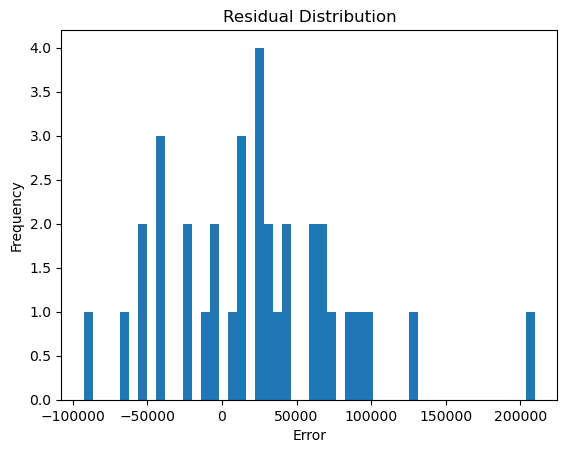

In [19]:
plt.hist(residuals, 50)
plt.title('Residual Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

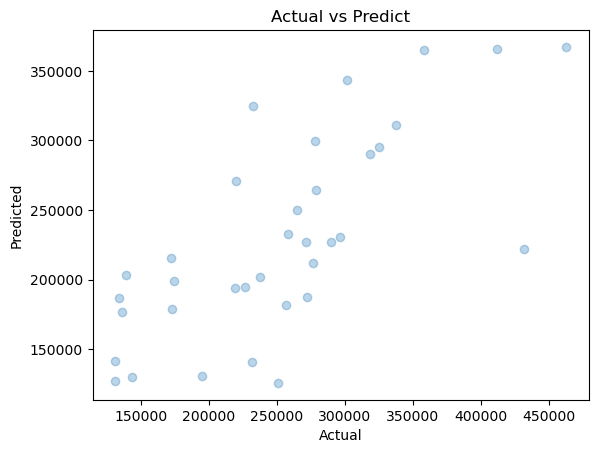

In [20]:
plt.scatter(y_test, y_pred, alpha = 0.3)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predict')
plt.show()

## Feature Impact

In [21]:
import pandas as pd

In [22]:
model.intercept_

np.float64(-1481702.010033437)

In [23]:
feature_importance = pd.Series(model.coef_, index = X.columns)
feature_importance.sort_values(ascending=False)

district_大安區                   102796.957067
district_信義區                    29875.163030
district_中正區                    18880.611324
area_ratio                       7180.944976
log_area                         2545.349224
building_year                    1398.617599
transaction_month                1109.322279
parking_area                      405.278107
main_area                         346.064048
area                              -93.648538
floor_level                      -211.250140
transaction_year                 -442.509342
net_area                         -498.926645
district_松山區                     -576.498578
total_floors                     -576.938923
building_age                    -1841.126942
time_index                      -4200.789829
has_parking                    -12925.641955
district_大同區                   -19322.134201
building_type_公寓(5樓含以下無電梯)     -22737.924120
district_士林區                   -22934.530515
district_內湖區                   -30649.448116
building_t

In [24]:
X.columns

Index(['area', 'main_area', 'net_area', 'parking_area', 'total_floors',
       'floor_level', 'building_year', 'building_age', 'transaction_year',
       'transaction_month', 'area_ratio', 'time_index', 'log_area',
       'has_parking', 'district_中正區', 'district_信義區', 'district_內湖區',
       'district_北投區', 'district_南港區', 'district_士林區', 'district_大同區',
       'district_大安區', 'district_文山區', 'district_松山區', 'district_萬華區',
       'building_type_公寓(5樓含以下無電梯)', 'building_type_華廈(10層含以下有電梯)'],
      dtype='object')

# Notes

## Key Insights

- **Location dominates pricing**
  - District features are the strongest predictors by a large margin
  - Confirms real-world importance of location in housing prices

- **Area-related features are important but redundant**
  - Features like `area`, `main_area`, `net_area`, `log_area`, `area_ratio` all contribute
  - Conflicting coefficient signs suggest overlap in information

- **Core structural features behave as expected**
  - `building_age` (negative) and `building_year` (positive) align with intuition
  - Newer properties tend to have higher prices

- **Some features show weak or unstable signals**
  - `floor_level`, `total_floors`, and time-related features have limited impact
  - May be noisy or less relevant in current dataset

## Key Modeling Issues

- **Multicollinearity (High Priority)**
  - Strong correlation among area-related features
  - Leads to unstable and hard-to-interpret coefficients

- **Feature redundancy**
  - Multiple features representing similar concepts (area, time)
  - Adds noise without clear performance gain

- **Over-reliance on district features**
  - Model depends heavily on location as a shortcut
  - May limit deeper understanding of price drivers

- **Negative intercept (not a bug)**
  - Caused by unscaled features and large coefficient offsets
  - Does not affect model validity

# Clean Baseline v2

In [33]:
importlib.reload(data_prep)
importlib.reload(features)

<module 'features' from 'c:\\Users\\User\\Desktop\\test_proj\\ml\\features.py'>

In [34]:
df = data_prep.prepare_dataset()

X_v2 = df.drop(columns=['final_price_per_sqm'])
y_v2 = df['final_price_per_sqm']

Districts:  ['中正區', '文山區', '大同區', '萬華區', '內湖區', '中山區', '士林區', '大安區', '信義區', '松山區', '南港區', '北投區']
Building_type:  ['華廈(10層含以下有電梯)', '住宅大樓(11層含以上有電梯)', '公寓(5樓含以下無電梯)']


## Remove redundant features

In [37]:
# Drop correlated area features
cols_to_drop = [
    'area',
    'main_area',
    'net_area'
]
X_v2 = X_v2.drop(columns=cols_to_drop)

# Simplify time features
X_v2 = X_v2.drop(columns=['transaction_year', 'transaction_month', 'building_year'])

# Handle weak/noisy features
X_v2 = X_v2.drop(columns=['floor_level'])

In [38]:
X_v2.columns

Index(['parking_area', 'total_floors', 'building_age', 'area_ratio',
       'time_index', 'log_area', 'has_parking', 'district_中正區', 'district_信義區',
       'district_內湖區', 'district_北投區', 'district_南港區', 'district_士林區',
       'district_大同區', 'district_大安區', 'district_文山區', 'district_松山區',
       'district_萬華區', 'building_type_公寓(5樓含以下無電梯)',
       'building_type_華廈(10層含以下有電梯)'],
      dtype='object')

## Train test split

In [39]:

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size = 0.2,
    random_state = 42
)

## Scaling

In [40]:
num_cols = [
    'log_area',
    'area_ratio',
    'building_age',
    'total_floors',
    'parking_area',
    'time_index'
]

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

X_train_v2[num_cols] = scaler.fit_transform(X_train_v2[num_cols])
X_test_v2[num_cols] = scaler.transform(X_test_v2[num_cols])

In [43]:
X_train_v2[num_cols].describe()

,log_area,area_ratio,building_age,total_floors,parking_area,time_index
count,1.360000e+02,1.360000e+02,1.360000e+02,1.360000e+02,1.360000e+02,1.360000e+02
mean,4.114356e-16,-2.351061e-16,5.224579e-17,1.044916e-16,-2.612289e-17,-2.677597e-16
std,1.003697e+00,1.003697e+00,1.003697e+00,1.003697e+00,1.003697e+00,1.003697e+00
min,-3.886298e+00,-2.058389e+00,-1.921670e+00,-1.406900e+00,-3.449193e-01,-7.057848e+00
25%,-6.525744e-01,-7.842323e-01,-8.609600e-01,-9.321146e-01,-3.449193e-01,-1.613486e-01
50%,8.223241e-02,3.022323e-02,2.881421e-01,-2.199372e-01,-3.449193e-01,-1.613486e-01
75%,5.765503e-01,8.004184e-01,8.479611e-01,7.296328e-01,-3.449193e-01,4.656059e-01
max,2.228052e+00,1.614044e+00,1.496173e+00,4.053128e+00,7.307108e+00,1.092560e+00


## Retrain Model

In [44]:
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

In [45]:
rmse_v2 = np.sqrt(mean_squared_error(y_pred_v2, y_test_v2))
mae_v2 = mean_absolute_error(y_pred_v2, y_test_v2)

print(f'RMSE v2: {rmse_v2:,.2f}')
print(f'MAE v2: {mae_v2:,.2f}')

RMSE v2: 59,696.36
MAE v2: 45,738.04


## Residual Analysis

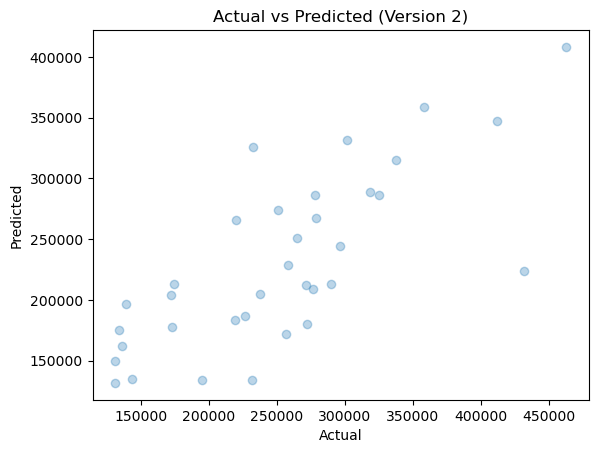

In [46]:
plt.scatter(y_test_v2, y_pred_v2, alpha=0.3)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Version 2)')
plt.show()

## Feature impact

In [47]:
model_v2.intercept_

np.float64(275223.6656637115)

In [48]:
feature_importance_v2 = pd.Series(model_v2.coef_, index = X_v2.columns)
feature_importance_v2.sort_values(ascending=False)

district_大安區                   106065.067303
district_信義區                    32943.946708
district_中正區                    22003.209481
area_ratio                       6563.704873
parking_area                     6337.311954
district_松山區                    -1806.863153
total_floors                    -5944.897442
has_parking                     -6980.245723
time_index                     -10241.218437
district_大同區                   -14434.816162
log_area                       -20457.293551
building_type_公寓(5樓含以下無電梯)     -25325.380349
district_內湖區                   -25527.250652
district_士林區                   -28502.525593
building_type_華廈(10層含以下有電梯)    -42684.244840
building_age                   -55616.344617
district_文山區                   -64518.390945
district_萬華區                   -67258.170097
district_南港區                   -68250.591653
district_北投區                   -81949.533272
dtype: float64

# Notes

## Key Insights

- **Location remains the dominant driver**
  - District features continue to have the largest impact on pricing
  - Confirms that location explains most of the variance in price per sqm

- **Feature selection improved signal clarity**
  - Removing redundant area and time features reduced noise
  - Coefficients are now more stable and easier to interpret

- **Scaling makes coefficients comparable**
  - All numeric features are standardized (mean = 0, std = 1)
  - Coefficients now reflect relative importance across features

- **Size effect is clearly captured**
  - `log_area` is negative → larger properties have lower price per sqm
  - `area_ratio` is positive → better space efficiency increases value

- **Building age shows a consistent negative impact**
  - `building_age` is negative and stable after removing redundancy
  - Older buildings are associated with lower prices

- **Model intercept is now meaningful**
  - Intercept (~275k) approximates baseline price per sqm
  - Represents an average property with standardized features


## Key Modeling Improvements

- **Reduced multicollinearity**
  - Dropped redundant features (`area`, `main_area`, `net_area`, `building_year`)
  - Eliminated unstable and inflated coefficients

- **Simplified feature set**
  - Removed overlapping time features and noisy `floor_level`
  - Retained only meaningful and reliable predictors

- **Improved interpretability**
  - Coefficients now align better with real-world expectations
  - Feature importance hierarchy is clearer and more consistent

- **More stable linear model**
  - Less sensitivity to feature interactions
  - Better foundation for further modeling (regularization, advanced models)